# CommerceIQ E-commerce Price Elasticity Analysis

## Case Study: Conglomerate Inc - Promotional Strategy Analysis

This notebook analyzes price elasticity and promotional effectiveness across three categories:
- **Diapers**
- **Headphones** 
- **Breakfast Cereals**

**Data Period:** 2017-2019

---

## Table of Contents

1. [Data Loading and Preprocessing](#data-loading)
2. [Section 1: Sale Events Identification](#section-1)
3. [Section 2: Price Distribution and SKU Segmentation](#section-2)
4. [Section 3: Price Trend Analysis](#section-3)
5. [Bonus: Consumer Behavior Analysis](#bonus)
6. [Additional Data Recommendations](#recommendations)


In [26]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configuration
DATA_FILE = 'ecom-elasticity-data1.tsv'
OUTPUT_DIR = 'outputs'

# Create output directory for visualizations
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("="*80)
print("COMMERCEIQ E-COMMERCE PRICE ELASTICITY ANALYSIS")
print("="*80)


COMMERCEIQ E-COMMERCE PRICE ELASTICITY ANALYSIS


## 1. Data Loading and Preprocessing {#data-loading}


In [27]:
def load_data(file_path):
    """
    Load and preprocess the e-commerce data.
    
    Assumptions:
    - Data is tab-separated
    - Columns: ASIN, Category, Date, Price, Units_Sold
    - Date format: YYYY-MM-DD
    """
    df = pd.read_csv(file_path, sep='\t', header=None, 
                     names=['ASIN', 'Category', 'Date', 'Price', 'Units_Sold'])
    
    # Convert Date to datetime
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Extract year and month for analysis
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['YearMonth'] = df['Date'].dt.to_period('M')
    
    # Calculate revenue
    df['Revenue'] = df['Price'] * df['Units_Sold']
    
    print(f"✓ Data loaded successfully!")
    print(f"  - Total records: {len(df):,}")
    print(f"  - Date range: {df['Date'].min()} to {df['Date'].max()}")
    print(f"  - Categories: {df['Category'].unique().tolist()}")
    print(f"  - Unique ASINs: {df['ASIN'].nunique():,}")
    
    return df

df = load_data(DATA_FILE)
df.head()


✓ Data loaded successfully!
  - Total records: 462,000
  - Date range: 2017-01-01 00:00:00 to 2020-01-05 00:00:00
  - Categories: ['Diapers', 'Headphones', 'Cereals']
  - Unique ASINs: 420


,ASIN,Category,Date,Price,Units_Sold,Year,Month,YearMonth,Revenue
0,D9775,Diapers,2017-01-01,12.46,94,2017,1,2017-01,1171.24
1,D80,Diapers,2017-01-01,11.56,102,2017,1,2017-01,1179.12
2,D3248,Diapers,2017-01-01,12.21,93,2017,1,2017-01,1135.53
3,D1714,Diapers,2017-01-01,11.54,75,2017,1,2017-01,865.50
4,D1408,Diapers,2017-01-01,13.16,94,2017,1,2017-01,1237.04


## 2. Section 1: Sale Events Identification {#section-1}

### Objective
Identify sale events and calculate the spike in sales during these events.


In [28]:
# Import the analysis functions from the Python script
# For notebook, we'll run the analysis directly

from datetime import timedelta

def identify_sale_events(df, window_days=7, threshold_multiplier=1.5):
    """
    Identify sale events by detecting significant spikes in sales volume.
    
    Methodology:
    1. Calculate rolling average sales for each category
    2. Identify days where sales exceed threshold (default: 1.5x rolling average + 1.5 std dev)
    3. Group consecutive high-sales days into sale events
    4. Calculate spike magnitude as ratio of sale period to baseline
    """
    sale_events = []
    
    for category in df['Category'].unique():
        cat_df = df[df['Category'] == category].copy()
        
        # Calculate daily total sales per category
        daily_sales = cat_df.groupby('Date')['Units_Sold'].sum().reset_index()
        daily_sales = daily_sales.sort_values('Date')
        
        # Calculate rolling average (30-day window)
        daily_sales['Rolling_Avg'] = daily_sales['Units_Sold'].rolling(
            window=30, min_periods=7, center=True
        ).mean()
        
        # Calculate rolling standard deviation
        daily_sales['Rolling_Std'] = daily_sales['Units_Sold'].rolling(
            window=30, min_periods=7, center=True
        ).std()
        
        # Identify spikes (sales > threshold * rolling average + threshold * std)
        daily_sales['Is_Spike'] = (
            daily_sales['Units_Sold'] > 
            (daily_sales['Rolling_Avg'] + threshold_multiplier * daily_sales['Rolling_Std'])
        )
        
        # Group consecutive spike days into events
        daily_sales['Event_Group'] = (
            (daily_sales['Is_Spike'] != daily_sales['Is_Spike'].shift()).cumsum()
        )
        
        # Calculate metrics for each potential event
        for event_id in daily_sales[daily_sales['Is_Spike']]['Event_Group'].unique():
            event_data = daily_sales[daily_sales['Event_Group'] == event_id]
            
            if len(event_data) >= 1:
                event_start = event_data['Date'].min()
                event_end = event_data['Date'].max()
                event_duration = (event_end - event_start).days + 1
                
                # Calculate baseline (30 days before event)
                baseline_start = event_start - timedelta(days=30)
                baseline_data = daily_sales[
                    (daily_sales['Date'] >= baseline_start) & 
                    (daily_sales['Date'] < event_start)
                ]
                
                if len(baseline_data) > 0:
                    baseline_avg = baseline_data['Units_Sold'].mean()
                    event_avg = event_data['Units_Sold'].mean()
                    spike_multiplier = event_avg / baseline_avg if baseline_avg > 0 else 0
                    
                    sale_events.append({
                        'Category': category,
                        'Event_Start': event_start,
                        'Event_End': event_end,
                        'Duration_Days': event_duration,
                        'Baseline_Sales': baseline_avg,
                        'Event_Sales': event_avg,
                        'Spike_Multiplier': spike_multiplier,
                        'Total_Units_Sold': event_data['Units_Sold'].sum()
                    })
    
    sale_events_df = pd.DataFrame(sale_events)
    
    if len(sale_events_df) > 0:
        sale_events_df = sale_events_df.sort_values('Event_Start')
        print(f"\n✓ Identified {len(sale_events_df)} sale events across all categories")
        print(f"\nTop 10 Sale Events by Spike Magnitude:")
        display(sale_events_df.nlargest(10, 'Spike_Multiplier')[
            ['Category', 'Event_Start', 'Duration_Days', 'Spike_Multiplier', 'Total_Units_Sold']
        ])
    
    return sale_events_df

sale_events = identify_sale_events(df)



✓ Identified 196 sale events across all categories

Top 10 Sale Events by Spike Magnitude:


,Category,Event_Start,Duration_Days,Spike_Multiplier,Total_Units_Sold
123,Headphones,2019-07-15,2,3.962400,29065
186,Cereals,2019-07-15,2,3.961480,43543
145,Cereals,2017-07-17,2,3.882868,26513
84,Headphones,2017-07-17,2,3.866542,17725
166,Cereals,2018-07-16,2,3.829330,33162
102,Headphones,2018-07-16,2,3.802875,22044
63,Diapers,2019-07-15,2,3.418633,14998
36,Diapers,2018-07-16,2,3.267791,11434
13,Diapers,2017-07-17,2,3.186504,8758
172,Cereals,2018-12-01,2,2.884130,22870



✓ Sale events visualization saved


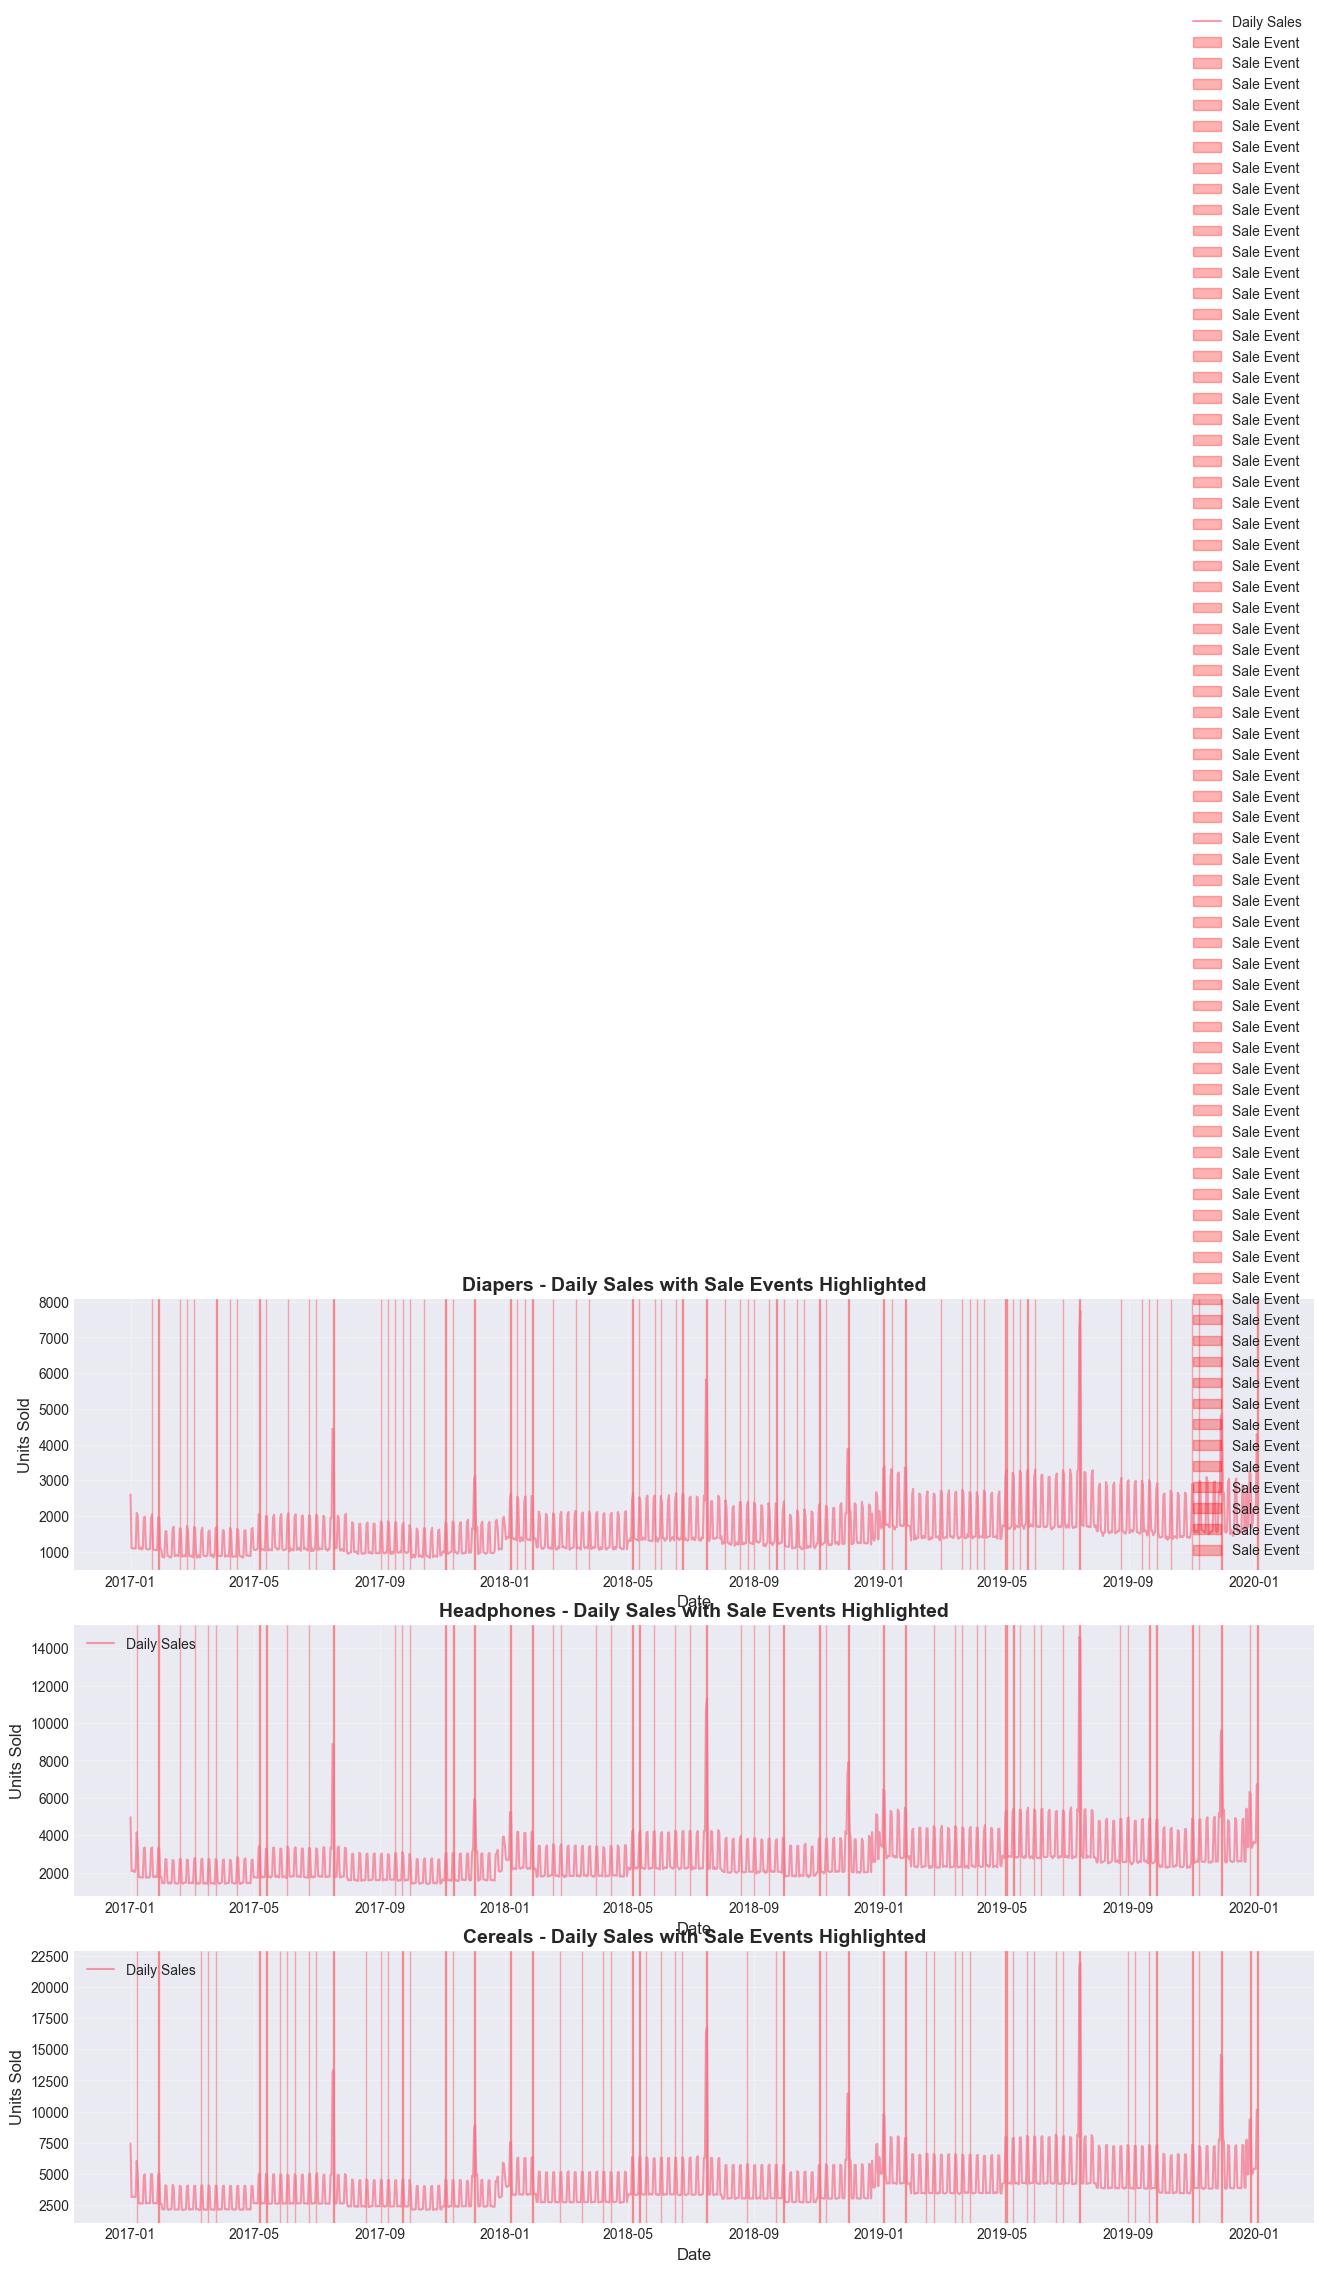

In [29]:
# Visualize sale events
def plot_sale_events(df, sale_events):
    """Create visualizations for sale events"""
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    
    for idx, category in enumerate(df['Category'].unique()):
        cat_df = df[df['Category'] == category].copy()
        daily_sales = cat_df.groupby('Date')['Units_Sold'].sum().reset_index()
        
        ax = axes[idx]
        ax.plot(daily_sales['Date'], daily_sales['Units_Sold'], 
                linewidth=1.5, alpha=0.7, label='Daily Sales')
        
        # Highlight sale events
        cat_events = sale_events[sale_events['Category'] == category]
        for _, event in cat_events.iterrows():
            ax.axvspan(event['Event_Start'], event['Event_End'], 
                      alpha=0.3, color='red', label='Sale Event' if idx == 0 else '')
        
        ax.set_title(f'{category} - Daily Sales with Sale Events Highlighted', 
                    fontsize=14, fontweight='bold')
        ax.set_xlabel('Date', fontsize=12)
        ax.set_ylabel('Units Sold', fontsize=12)
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/sale_events_analysis.png', dpi=300, bbox_inches='tight')
    print(f"\n✓ Sale events visualization saved")
    plt.show()

plot_sale_events(df, sale_events)


## 3. Section 2: Price Distribution and SKU Segmentation {#section-2}

### Objective
Analyze price distribution and segment SKUs into 'Top Selling', 'Core', and 'Tail' subcategories.


In [30]:
def segment_skus(df):
    """
    Segment SKUs into 'Top Selling', 'Core', and 'Tail' subcategories.
    
    Methodology (Pareto-based segmentation):
    1. Calculate total sales volume per ASIN across entire period
    2. Sort ASINs by total sales volume (descending)
    3. Calculate cumulative sales percentage
    4. Top Selling: Top 20% of ASINs by volume (typically 80/20 rule)
    5. Core: Next 30% of ASINs (21-50%)
    6. Tail: Remaining 50% of ASINs (bottom 50%)
    """
    sku_segments = []
    
    for category in df['Category'].unique():
        cat_df = df[df['Category'] == category].copy()
        
        # Calculate total sales per ASIN
        asin_sales = cat_df.groupby('ASIN').agg({
            'Units_Sold': 'sum',
            'Revenue': 'sum',
            'Price': 'mean'
        }).reset_index()
        asin_sales = asin_sales.sort_values('Units_Sold', ascending=False)
        
        # Calculate cumulative percentage
        asin_sales['Cumulative_Units'] = asin_sales['Units_Sold'].cumsum()
        asin_sales['Cumulative_Pct'] = (
            asin_sales['Cumulative_Units'] / asin_sales['Units_Sold'].sum() * 100
        )
        
        # Segment based on cumulative percentage
        asin_sales['Segment'] = 'Tail'  # Default
        asin_sales.loc[asin_sales['Cumulative_Pct'] <= 20, 'Segment'] = 'Top Selling'
        asin_sales.loc[
            (asin_sales['Cumulative_Pct'] > 20) & 
            (asin_sales['Cumulative_Pct'] <= 50), 
            'Segment'
        ] = 'Core'
        
        # Add category info
        asin_sales['Category'] = category
        sku_segments.append(asin_sales)
        
        # Print summary
        print(f"\n{category} - SKU Segmentation:")
        segment_summary = asin_sales.groupby('Segment').agg({
            'ASIN': 'count',
            'Units_Sold': 'sum',
            'Revenue': 'sum'
        })
        segment_summary.columns = ['SKU_Count', 'Total_Units', 'Total_Revenue']
        segment_summary['Pct_of_SKUs'] = (
            segment_summary['SKU_Count'] / len(asin_sales) * 100
        )
        segment_summary['Pct_of_Volume'] = (
            segment_summary['Total_Units'] / asin_sales['Units_Sold'].sum() * 100
        )
        display(segment_summary)
    
    sku_segments_df = pd.concat(sku_segments, ignore_index=True)
    return sku_segments_df

sku_segments = segment_skus(df)



Diapers - SKU Segmentation:


,SKU_Count,Total_Units,Total_Revenue,Pct_of_SKUs,Pct_of_Volume
Segment,,,,,
Core,14,532690,5737958.08,14.0,29.855473
Tail,80,896973,7516786.49,80.0,50.272302
Top Selling,6,354566,4233359.49,6.0,19.872225



Headphones - SKU Segmentation:


,SKU_Count,Total_Units,Total_Revenue,Pct_of_SKUs,Pct_of_Volume
Segment,,,,,
Core,17,918491,9.211719e+07,14.166667,30.537306
Tail,96,1504609,1.012056e+08,80.000000,50.024121
Top Selling,7,584667,6.968589e+07,5.833333,19.438574



Cereals - SKU Segmentation:


,SKU_Count,Total_Units,Total_Revenue,Pct_of_SKUs,Pct_of_Volume
Segment,,,,,
Core,27,1313372,16743517.19,13.5,29.192772
Tail,161,2286115,21997740.33,80.5,50.814265
Top Selling,12,899476,13448506.38,6.0,19.992963



✓ Price distribution and segmentation visualization saved


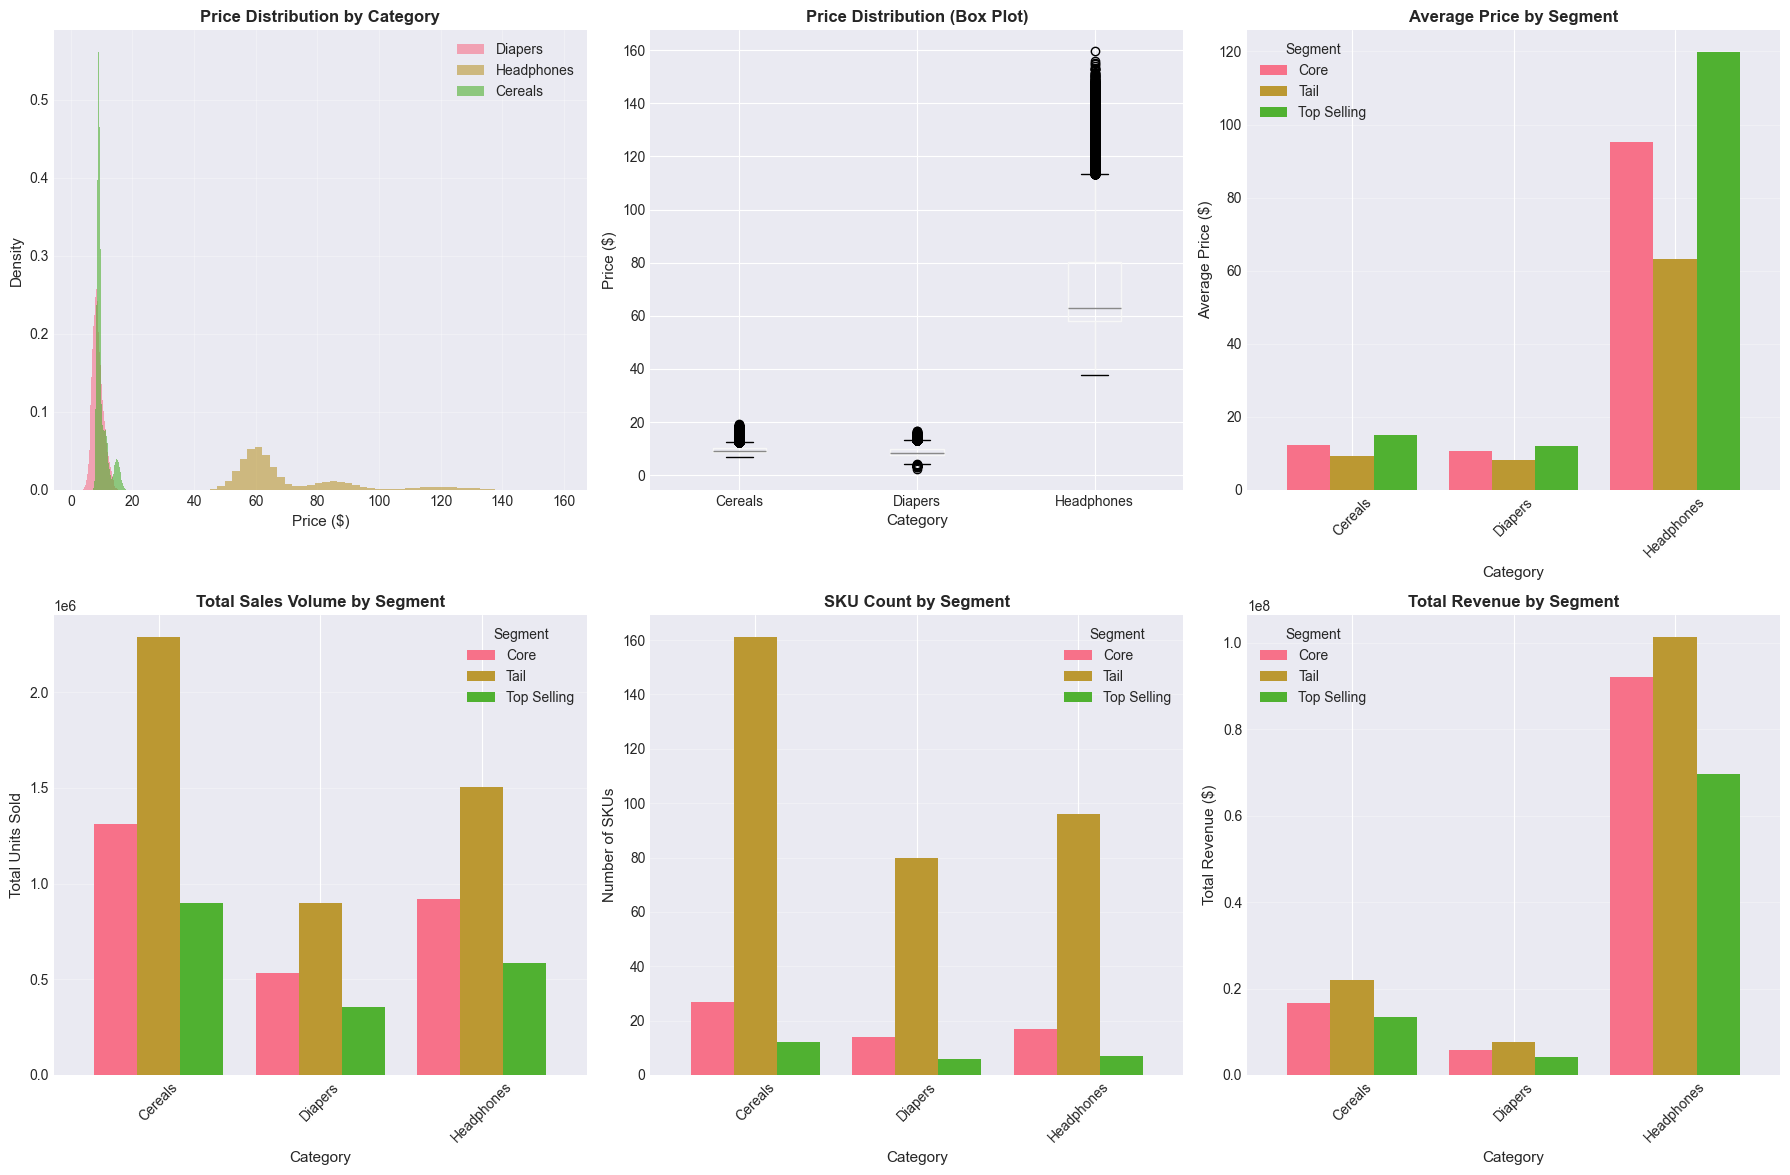

In [31]:
# Visualize price distribution and segmentation
def plot_price_distribution_and_segments(df, sku_segments):
    """Create visualizations for price distribution and SKU segments"""
    fig = plt.figure(figsize=(18, 12))
    
    # Price distribution by category
    ax1 = plt.subplot(2, 3, 1)
    for category in df['Category'].unique():
        cat_df = df[df['Category'] == category]
        ax1.hist(cat_df['Price'], bins=50, alpha=0.6, label=category, density=True)
    ax1.set_xlabel('Price ($)', fontsize=11)
    ax1.set_ylabel('Density', fontsize=11)
    ax1.set_title('Price Distribution by Category', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Box plot of prices by category
    ax2 = plt.subplot(2, 3, 2)
    df.boxplot(column='Price', by='Category', ax=ax2)
    ax2.set_xlabel('Category', fontsize=11)
    ax2.set_ylabel('Price ($)', fontsize=11)
    ax2.set_title('Price Distribution (Box Plot)', fontsize=12, fontweight='bold')
    plt.suptitle('')
    
    # Price by segment
    ax3 = plt.subplot(2, 3, 3)
    segment_price = sku_segments.groupby(['Category', 'Segment'])['Price'].mean().unstack()
    segment_price.plot(kind='bar', ax=ax3, width=0.8)
    ax3.set_xlabel('Category', fontsize=11)
    ax3.set_ylabel('Average Price ($)', fontsize=11)
    ax3.set_title('Average Price by Segment', fontsize=12, fontweight='bold')
    ax3.legend(title='Segment')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Sales volume by segment
    ax4 = plt.subplot(2, 3, 4)
    segment_volume = sku_segments.groupby(['Category', 'Segment'])['Units_Sold'].sum().unstack()
    segment_volume.plot(kind='bar', ax=ax4, width=0.8)
    ax4.set_xlabel('Category', fontsize=11)
    ax4.set_ylabel('Total Units Sold', fontsize=11)
    ax4.set_title('Total Sales Volume by Segment', fontsize=12, fontweight='bold')
    ax4.legend(title='Segment')
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3, axis='y')
    
    # SKU count by segment
    ax5 = plt.subplot(2, 3, 5)
    segment_count = sku_segments.groupby(['Category', 'Segment']).size().unstack()
    segment_count.plot(kind='bar', ax=ax5, width=0.8)
    ax5.set_xlabel('Category', fontsize=11)
    ax5.set_ylabel('Number of SKUs', fontsize=11)
    ax5.set_title('SKU Count by Segment', fontsize=12, fontweight='bold')
    ax5.legend(title='Segment')
    ax5.tick_params(axis='x', rotation=45)
    ax5.grid(True, alpha=0.3, axis='y')
    
    # Revenue by segment
    ax6 = plt.subplot(2, 3, 6)
    segment_revenue = sku_segments.groupby(['Category', 'Segment'])['Revenue'].sum().unstack()
    segment_revenue.plot(kind='bar', ax=ax6, width=0.8)
    ax6.set_xlabel('Category', fontsize=11)
    ax6.set_ylabel('Total Revenue ($)', fontsize=11)
    ax6.set_title('Total Revenue by Segment', fontsize=12, fontweight='bold')
    ax6.legend(title='Segment')
    ax6.tick_params(axis='x', rotation=45)
    ax6.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/price_distribution_segmentation.png', dpi=300, bbox_inches='tight')
    print(f"\n✓ Price distribution and segmentation visualization saved")
    plt.show()

plot_price_distribution_and_segments(df, sku_segments)


## 4. Section 3: Price Trend Analysis {#section-3}

### Objective
Determine which category is getting more expensive and understand the drivers (existing SKU price increases vs new SKU introductions).


In [32]:
def analyze_price_trends(df):
    """Analyze price trends to determine which category is getting more expensive."""
    price_trends = []
    
    # Calculate monthly average prices by category
    monthly_prices = df.groupby(['Category', 'YearMonth'])['Price'].mean().reset_index()
    monthly_prices['Year'] = monthly_prices['YearMonth'].astype(str).str[:4].astype(int)
    monthly_prices['Month'] = monthly_prices['YearMonth'].astype(str).str[5:].astype(int)
    
    # Calculate year-over-year price change
    for category in df['Category'].unique():
        cat_monthly = monthly_prices[monthly_prices['Category'] == category].copy()
        cat_monthly = cat_monthly.sort_values(['Year', 'Month'])
        
        # Year-over-year comparison
        for year in [2018, 2019]:
            year_data = cat_monthly[cat_monthly['Year'] == year]
            prev_year_data = cat_monthly[cat_monthly['Year'] == year - 1]
            
            if len(year_data) > 0 and len(prev_year_data) > 0:
                avg_price_current = year_data['Price'].mean()
                avg_price_previous = prev_year_data['Price'].mean()
                yoy_change = ((avg_price_current - avg_price_previous) / avg_price_previous) * 100
                
                price_trends.append({
                    'Category': category,
                    'Year': year,
                    'Avg_Price': avg_price_current,
                    'YoY_Change_Pct': yoy_change
                })
        
        print(f"\n{category} - Price Trend Summary:")
        print(f"  2017 Average Price: ${cat_monthly[cat_monthly['Year']==2017]['Price'].mean():.2f}")
        print(f"  2018 Average Price: ${cat_monthly[cat_monthly['Year']==2018]['Price'].mean():.2f}")
        print(f"  2019 Average Price: ${cat_monthly[cat_monthly['Year']==2019]['Price'].mean():.2f}")
    
    price_trends_df = pd.DataFrame(price_trends)
    
    # Analyze existing vs new SKUs
    print("\n" + "-"*80)
    print("Analyzing Existing SKUs vs New SKUs:")
    
    for category in df['Category'].unique():
        cat_df = df[df['Category'] == category].copy()
        
        # Identify SKUs that existed in 2017
        skus_2017 = set(cat_df[cat_df['Year'] == 2017]['ASIN'].unique())
        skus_2018 = set(cat_df[cat_df['Year'] == 2018]['ASIN'].unique())
        skus_2019 = set(cat_df[cat_df['Year'] == 2019]['ASIN'].unique())
        
        existing_skus_2018 = skus_2017.intersection(skus_2018)
        existing_skus_2019 = skus_2017.intersection(skus_2019)
        new_skus_2018 = skus_2018 - skus_2017
        new_skus_2019 = skus_2019 - skus_2017
        
        # Calculate average prices
        existing_2017_price = cat_df[
            (cat_df['Year'] == 2017) & (cat_df['ASIN'].isin(skus_2017))
        ]['Price'].mean()
        
        existing_2018_price = cat_df[
            (cat_df['Year'] == 2018) & (cat_df['ASIN'].isin(existing_skus_2018))
        ]['Price'].mean()
        
        existing_2019_price = cat_df[
            (cat_df['Year'] == 2019) & (cat_df['ASIN'].isin(existing_skus_2019))
        ]['Price'].mean()
        
        new_2018_price = cat_df[
            (cat_df['Year'] == 2018) & (cat_df['ASIN'].isin(new_skus_2018))
        ]['Price'].mean() if len(new_skus_2018) > 0 else 0
        
        new_2019_price = cat_df[
            (cat_df['Year'] == 2019) & (cat_df['ASIN'].isin(new_skus_2019))
        ]['Price'].mean() if len(new_skus_2019) > 0 else 0
        
        print(f"\n{category}:")
        print(f"  Existing SKUs (2017): {len(skus_2017):,}")
        print(f"  New SKUs in 2018: {len(new_skus_2018):,} (Avg Price: ${new_2018_price:.2f})")
        print(f"  New SKUs in 2019: {len(new_skus_2019):,} (Avg Price: ${new_2019_price:.2f})")
        print(f"  Existing SKU Price Change:")
        print(f"    2017 → 2018: ${existing_2017_price:.2f} → ${existing_2018_price:.2f} "
              f"({((existing_2018_price/existing_2017_price - 1)*100):.1f}%)")
        print(f"    2017 → 2019: ${existing_2017_price:.2f} → ${existing_2019_price:.2f} "
              f"({((existing_2019_price/existing_2017_price - 1)*100):.1f}%)")
    
    return price_trends_df, monthly_prices

price_trends_df, monthly_prices = analyze_price_trends(df)



Diapers - Price Trend Summary:
  2017 Average Price: $8.80
  2018 Average Price: $8.80
  2019 Average Price: $8.80

Headphones - Price Trend Summary:
  2017 Average Price: $71.00
  2018 Average Price: $71.03
  2019 Average Price: $71.00

Cereals - Price Trend Summary:
  2017 Average Price: $10.00
  2018 Average Price: $10.00
  2019 Average Price: $10.00

--------------------------------------------------------------------------------
Analyzing Existing SKUs vs New SKUs:

Diapers:
  Existing SKUs (2017): 100
  New SKUs in 2018: 0 (Avg Price: $0.00)
  New SKUs in 2019: 0 (Avg Price: $0.00)
  Existing SKU Price Change:
    2017 → 2018: $8.80 → $8.80 (-0.1%)
    2017 → 2019: $8.80 → $8.80 (-0.0%)

Headphones:
  Existing SKUs (2017): 120
  New SKUs in 2018: 0 (Avg Price: $0.00)
  New SKUs in 2019: 0 (Avg Price: $0.00)
  Existing SKU Price Change:
    2017 → 2018: $71.00 → $71.03 (0.0%)
    2017 → 2019: $71.00 → $71.00 (0.0%)

Cereals:
  Existing SKUs (2017): 200
  New SKUs in 2018: 0 (Avg 


✓ Price trends visualization saved


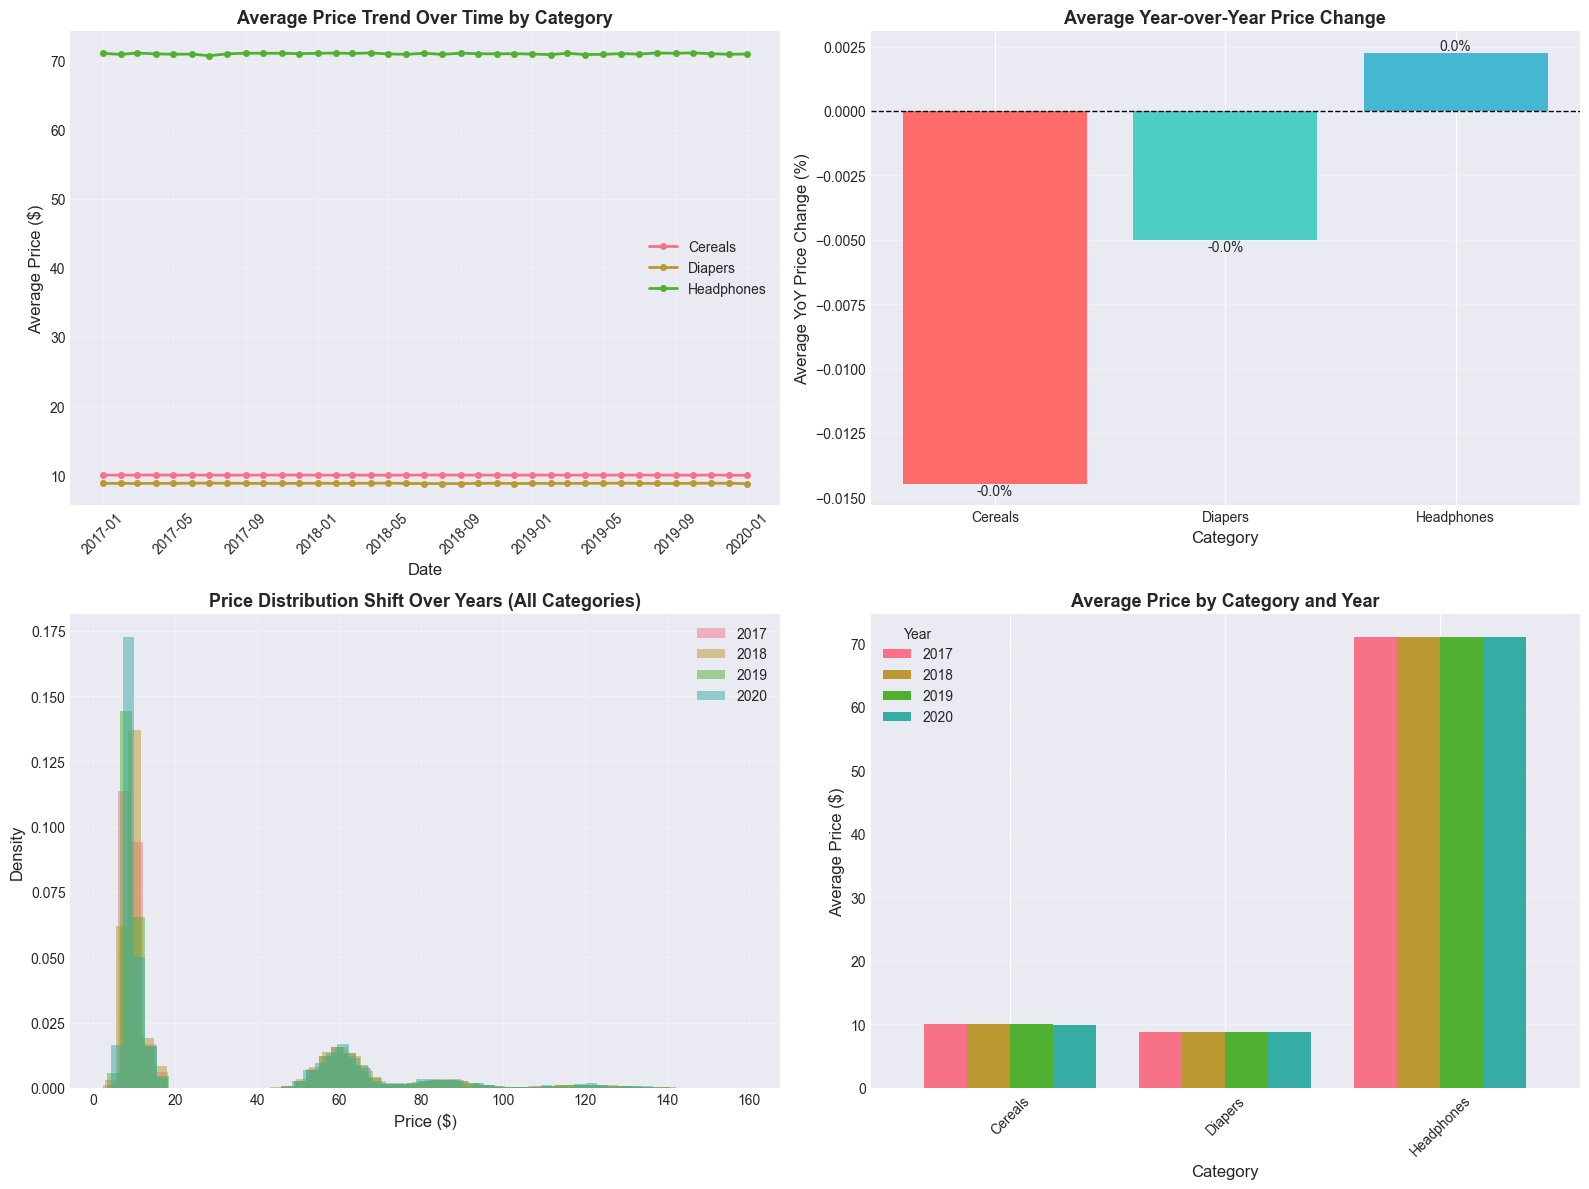

In [33]:
# Visualize price trends
def plot_price_trends(monthly_prices, df):
    """Create visualizations for price trends"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Time series of average prices
    ax1 = axes[0, 0]
    for category in monthly_prices['Category'].unique():
        cat_data = monthly_prices[monthly_prices['Category'] == category].copy()
        cat_data = cat_data.sort_values(['Year', 'Month'])
        cat_data['Date'] = pd.to_datetime(cat_data['YearMonth'].astype(str))
        ax1.plot(cat_data['Date'], cat_data['Price'], marker='o', 
                linewidth=2, label=category, markersize=4)
    ax1.set_xlabel('Date', fontsize=12)
    ax1.set_ylabel('Average Price ($)', fontsize=12)
    ax1.set_title('Average Price Trend Over Time by Category', fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    # Year-over-year price change
    ax2 = axes[0, 1]
    price_trends_summary = price_trends_df.groupby('Category')['YoY_Change_Pct'].mean().reset_index()
    bars = ax2.bar(price_trends_summary['Category'], price_trends_summary['YoY_Change_Pct'],
                   color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    ax2.set_xlabel('Category', fontsize=12)
    ax2.set_ylabel('Average YoY Price Change (%)', fontsize=12)
    ax2.set_title('Average Year-over-Year Price Change', fontsize=13, fontweight='bold')
    ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top')
    
    # Price distribution by year
    ax3 = axes[1, 0]
    years = sorted(df['Year'].unique())
    for year in years:
        year_data = df[df['Year'] == year]
        ax3.hist(year_data['Price'], bins=50, alpha=0.5, label=str(year), density=True)
    ax3.set_xlabel('Price ($)', fontsize=12)
    ax3.set_ylabel('Density', fontsize=12)
    ax3.set_title('Price Distribution Shift Over Years (All Categories)', fontsize=13, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Category comparison by year
    ax4 = axes[1, 1]
    yearly_avg = df.groupby(['Category', 'Year'])['Price'].mean().unstack()
    yearly_avg.plot(kind='bar', ax=ax4, width=0.8)
    ax4.set_xlabel('Category', fontsize=12)
    ax4.set_ylabel('Average Price ($)', fontsize=12)
    ax4.set_title('Average Price by Category and Year', fontsize=13, fontweight='bold')
    ax4.legend(title='Year')
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/price_trends_analysis.png', dpi=300, bbox_inches='tight')
    print(f"\n✓ Price trends visualization saved")
    plt.show()

plot_price_trends(monthly_prices, df)


## 5. Bonus: Consumer Behavior Analysis 

### Objective
Interpret data and present consumer behavior reasoning behind observed patterns.


In [34]:
def analyze_consumer_behavior(df, sale_events, sku_segments):
    """Analyze consumer behavior patterns from the data."""
    print("\nConsumer Behavior Insights:")
    
    # 1. Price Elasticity Analysis
    print("\n1. Price Elasticity Analysis:")
    for category in df['Category'].unique():
        cat_df = df[df['Category'] == category].copy()
        
        # Calculate correlation between price and sales
        price_sales_corr = cat_df.groupby('ASIN').apply(
            lambda x: x['Price'].corr(x['Units_Sold'])
        ).mean()
        
        # Calculate average price change impact
        cat_df_sorted = cat_df.sort_values(['ASIN', 'Date'])
        cat_df_sorted['Price_Change'] = cat_df_sorted.groupby('ASIN')['Price'].pct_change()
        cat_df_sorted['Sales_Change'] = cat_df_sorted.groupby('ASIN')['Units_Sold'].pct_change()
        
        # Filter for significant price changes (>5%)
        significant_changes = cat_df_sorted[
            (cat_df_sorted['Price_Change'].abs() > 0.05) & 
            (cat_df_sorted['Sales_Change'].notna())
        ]
        
        if len(significant_changes) > 0:
            elasticity = significant_changes['Sales_Change'].mean() / significant_changes['Price_Change'].mean()
            print(f"   {category}:")
            print(f"     Average Price-Sales Correlation: {price_sales_corr:.3f}")
            print(f"     Estimated Price Elasticity: {elasticity:.2f}")
            if elasticity < -1:
                print(f"     → Highly price-sensitive (elastic)")
            elif elasticity < 0:
                print(f"     → Moderately price-sensitive")
            else:
                print(f"     → Price-insensitive (inelastic)")
    
    # 2. Sale Event Response
    print("\n2. Sale Event Response Analysis:")
    for category in df['Category'].unique():
        cat_events = sale_events[sale_events['Category'] == category]
        if len(cat_events) > 0:
            avg_spike = cat_events['Spike_Multiplier'].mean()
            print(f"   {category}:")
            print(f"     Average Sales Spike During Events: {avg_spike:.2f}x baseline")
            print(f"     → Consumers respond {'strongly' if avg_spike > 2 else 'moderately'} to promotions")
    
    # 3. Segment Behavior
    print("\n3. Segment-Specific Behavior:")
    for category in df['Category'].unique():
        cat_segments = sku_segments[sku_segments['Category'] == category]
        top_selling = cat_segments[cat_segments['Segment'] == 'Top Selling']
        tail = cat_segments[cat_segments['Segment'] == 'Tail']
        
        print(f"   {category}:")
        print(f"     Top Selling SKUs: {len(top_selling)} SKUs, "
              f"Avg Price: ${top_selling['Price'].mean():.2f}")
        print(f"     Tail SKUs: {len(tail)} SKUs, "
              f"Avg Price: ${tail['Price'].mean():.2f}")
    
    # 4. Seasonal Patterns
    print("\n4. Seasonal Purchase Patterns:")
    df['Month'] = df['Date'].dt.month
    monthly_sales = df.groupby(['Category', 'Month'])['Units_Sold'].sum().reset_index()
    
    for category in df['Category'].unique():
        cat_monthly = monthly_sales[monthly_sales['Category'] == category]
        peak_month = cat_monthly.loc[cat_monthly['Units_Sold'].idxmax(), 'Month']
        peak_sales = cat_monthly['Units_Sold'].max()
        avg_sales = cat_monthly['Units_Sold'].mean()
        
        print(f"   {category}:")
        print(f"     Peak Sales Month: {peak_month} ({peak_sales/avg_sales:.1f}x average)")

analyze_consumer_behavior(df, sale_events, sku_segments)



Consumer Behavior Insights:

1. Price Elasticity Analysis:
   Diapers:
     Average Price-Sales Correlation: -0.418
     Estimated Price Elasticity: inf
     → Price-insensitive (inelastic)
   Headphones:
     Average Price-Sales Correlation: -0.364
     Estimated Price Elasticity: inf
     → Price-insensitive (inelastic)
   Cereals:
     Average Price-Sales Correlation: -0.199
     Estimated Price Elasticity: 10.52
     → Price-insensitive (inelastic)

2. Sale Event Response Analysis:
   Diapers:
     Average Sales Spike During Events: 1.70x baseline
     → Consumers respond moderately to promotions
   Headphones:
     Average Sales Spike During Events: 1.77x baseline
     → Consumers respond moderately to promotions
   Cereals:
     Average Sales Spike During Events: 1.76x baseline
     → Consumers respond moderately to promotions

3. Segment-Specific Behavior:
   Diapers:
     Top Selling SKUs: 6 SKUs, Avg Price: $11.99
     Tail SKUs: 80 SKUs, Avg Price: $8.26
   Headphones:
     

## 6. Additional Data Recommendations {#recommendations}

### What other data would be useful for promotional strategy?


### Key Recommendations:

1. **Competitive Data:** Competitor pricing, market share, promotional calendars
2. **Inventory Data:** Stock levels, inventory turnover, fulfillment speed
3. **Marketing Data:** Ad spend, channels, campaign details, CAC
4. **Customer Data:** Segments, demographics, purchase frequency, CLV
5. **Product Attributes:** Features, ratings, reviews, brand info
6. **External Factors:** Seasonal events, holidays, economic indicators
7. **Channel Data:** Sales by channel, channel-specific pricing
8. **Price History:** Historical promotional prices, discount depths

*See Supporting_Document.md for detailed explanations of how to use each data source.*


In [35]:
# Save all results to CSV files
print("\n" + "="*80)
print("SAVING RESULTS")
print("="*80)

sale_events.to_csv(f'{OUTPUT_DIR}/sale_events.csv', index=False)
sku_segments.to_csv(f'{OUTPUT_DIR}/sku_segments.csv', index=False)
price_trends_df.to_csv(f'{OUTPUT_DIR}/price_trends.csv', index=False)
monthly_prices.to_csv(f'{OUTPUT_DIR}/monthly_prices.csv', index=False)

print(f"✓ Results saved to {OUTPUT_DIR}/ directory:")
print(f"  - sale_events.csv")
print(f"  - sku_segments.csv")
print(f"  - price_trends.csv")
print(f"  - monthly_prices.csv")

# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

summary_stats = df.groupby('Category').agg({
    'ASIN': 'nunique',
    'Units_Sold': ['sum', 'mean'],
    'Revenue': ['sum', 'mean'],
    'Price': ['mean', 'std', 'min', 'max']
}).round(2)

print("\nOverall Statistics by Category:")
display(summary_stats)



SAVING RESULTS
✓ Results saved to outputs/ directory:
  - sale_events.csv
  - sku_segments.csv
  - price_trends.csv
  - monthly_prices.csv

SUMMARY STATISTICS

Overall Statistics by Category:


ASIN Units_Sold              Revenue           Price         \
           nunique        sum   mean           sum     mean   mean    std   
Category                                                                    
Cereals        200    4498963  20.45  5.218976e+07   237.23  10.00   1.97   
Diapers        100    1784229  16.22  1.748810e+07   158.98   8.80   1.79   
Headphones     120    3007767  22.79  2.630087e+08  1992.49  71.01  20.03   

                           
              min     max  
Category                   
Cereals      6.72   19.13  
Diapers      2.33   16.75  
Headphones  37.70  159.53